# Preprocessing

In [25]:
import os
import pandas as pd

# Load the data
df_churn = pd.read_csv("patient_churn_dataset.csv")

df_churn.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_20837/1304318499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=df_churn, palette=['#2ECC71', '#C8E6C9'])


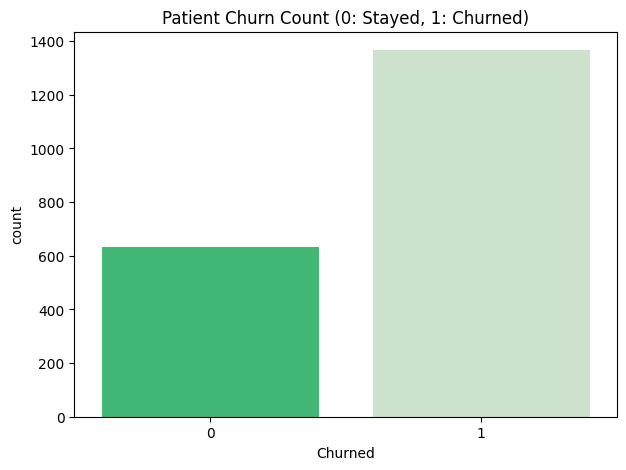

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Churned', data=df_churn, palette=['#2ECC71', '#C8E6C9'])
plt.title('Patient Churn Count (0: Stayed, 1: Churned)', color='black')
plt.show()

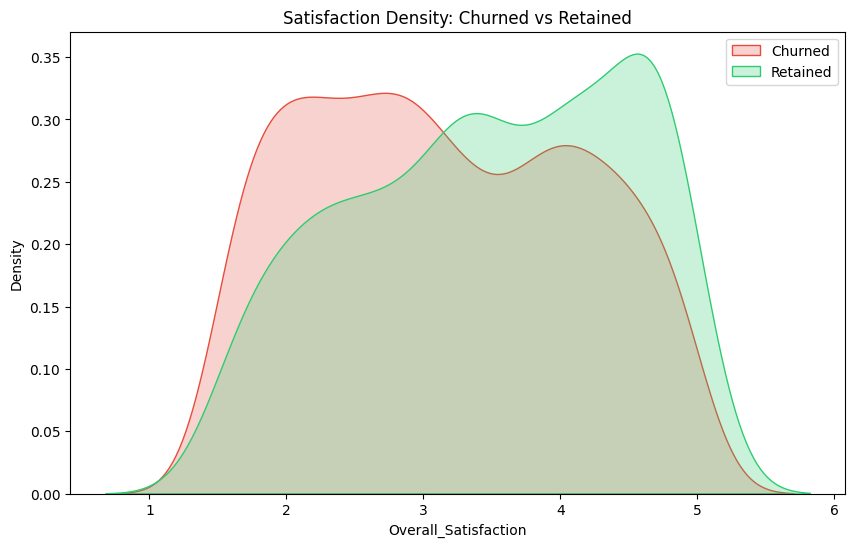

In [27]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_churn[df_churn['Churned'] == 1]['Overall_Satisfaction'], label='Churned', fill=True, color='#E74C3C')
sns.kdeplot(df_churn[df_churn['Churned'] == 0]['Overall_Satisfaction'], label='Retained', fill=True, color='#2ECC71')
plt.title('Satisfaction Density: Churned vs Retained', color='black')
plt.legend()
plt.show()

/var/folders/f8/ldzzvs9j1cd10hx6fnlqx0hc0000gp/T/ipykernel_20837/526594683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churned', y='Avg_Out_Of_Pocket_Cost', data=df_churn, palette='Greens')


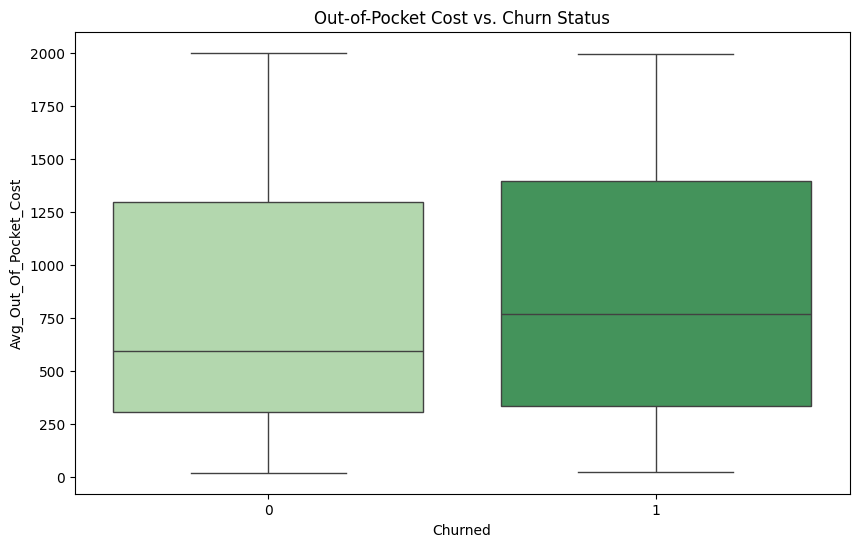

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churned', y='Avg_Out_Of_Pocket_Cost', data=df_churn, palette='Greens')
plt.title('Out-of-Pocket Cost vs. Churn Status', color='black')
plt.show()

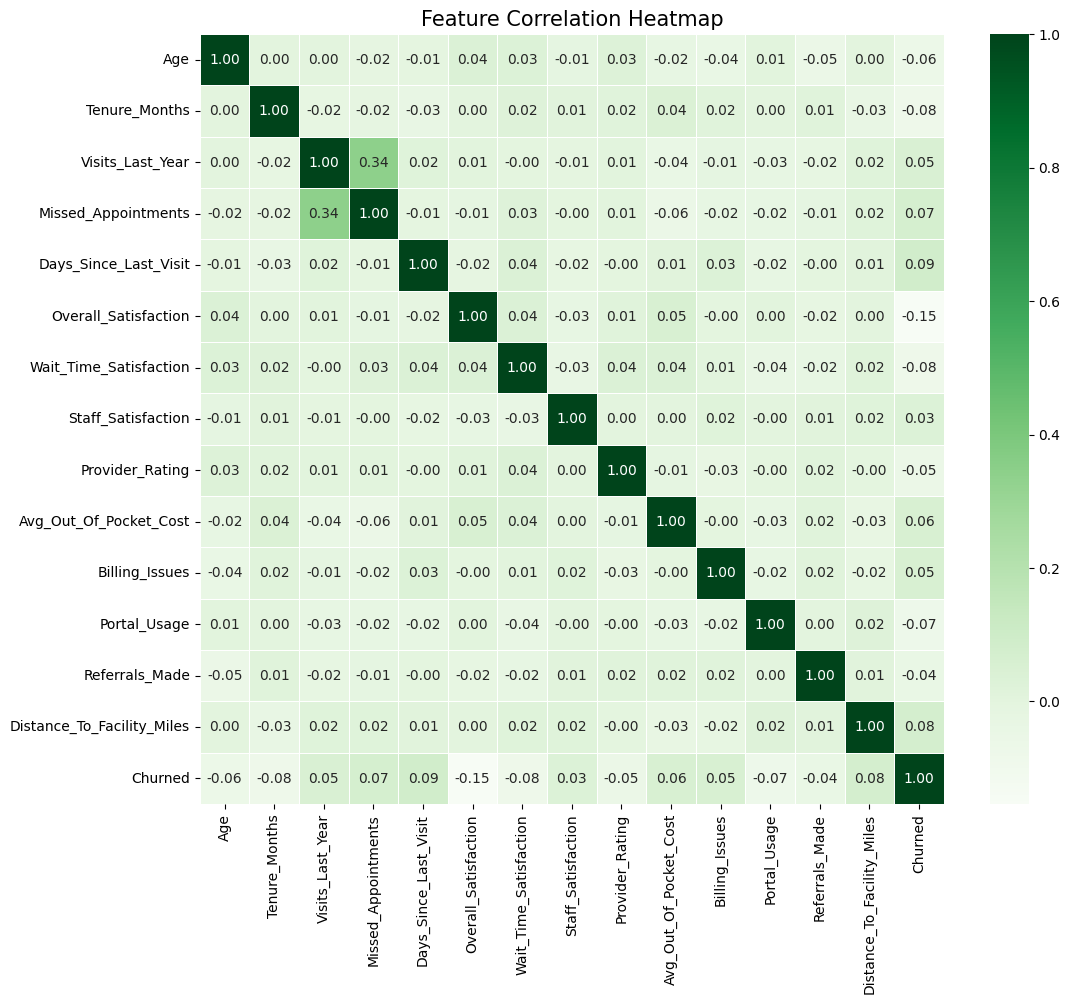

In [29]:
import numpy as np

plt.figure(figsize=(12, 10))
corr = df_churn.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Feature Correlation Heatmap', color='black', fontsize=15)
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features_to_scale = df_churn.select_dtypes(include=['int64', 'float64']).columns.drop('Churned')
df_churn[features_to_scale] = scaler.fit_transform(df_churn[features_to_scale])

In [31]:
unique_values = df_churn['Gender'].unique()
print(unique_values)

unique_values = df_churn['Specialty'].unique()
print(unique_values)

unique_values = df_churn['Insurance_Type'].unique()
print(unique_values)

<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
[       'Pediatrics', 'Internal Medicine',  'General Practice',
        'Cardiology',       'Orthopedics',         'Neurology',
   'Family Medicine']
Length: 7, dtype: str
<StringArray>
['Medicaid', 'Self-Pay', 'Private', 'Medicare']
Length: 4, dtype: str


In [32]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(df_churn[['Gender', 'Specialty', 'Insurance_Type']])

# Create a DataFrame with the new column names
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Gender', 'Specialty', 'Insurance_Type']))

# Concatenate with the original dataframe and drop the old categorical columns
df_churn = pd.concat([df_churn.drop(['Gender', 'Specialty', 'Insurance_Type'], axis=1), encoded_df], axis=1)

In [33]:
df_churn.head()

,PatientID,Age,State,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Last_Interaction_Date,Overall_Satisfaction,Wait_Time_Satisfaction,...,Gender_Male,Specialty_Family Medicine,Specialty_General Practice,Specialty_Internal Medicine,Specialty_Neurology,Specialty_Orthopedics,Specialty_Pediatrics,Insurance_Type_Medicare,Insurance_Type_Private,Insurance_Type_Self-Pay
0,C20000,-0.748870,PA,0.036080,-1.415979,-1.193723,0.929678,2024-07-05,0.242973,1.596039,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,C20001,-0.622547,GA,-0.476704,-0.131450,1.160760,-0.526835,2025-05-11,-0.649581,-0.188242,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,C20002,-2.012092,MI,1.688383,1.581255,1.749381,-1.302076,2025-10-23,-1.641307,1.100405,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C20003,0.766997,FL,1.631407,0.510814,0.572139,-1.085948,2025-09-07,-0.649581,1.001279,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,C20004,-2.201575,CA,0.263984,-0.559626,1.160760,1.549871,2024-02-24,-1.046271,0.703899,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
from sklearn.model_selection import train_test_split

# Removing non-predictive IDs and dates before model training.
X = df_churn.drop(['PatientID', 'Last_Interaction_Date', 'Churned', 'State'], axis=1)
y = df_churn['Churned']

## applying SMOTE for class inbalance

<Axes: >

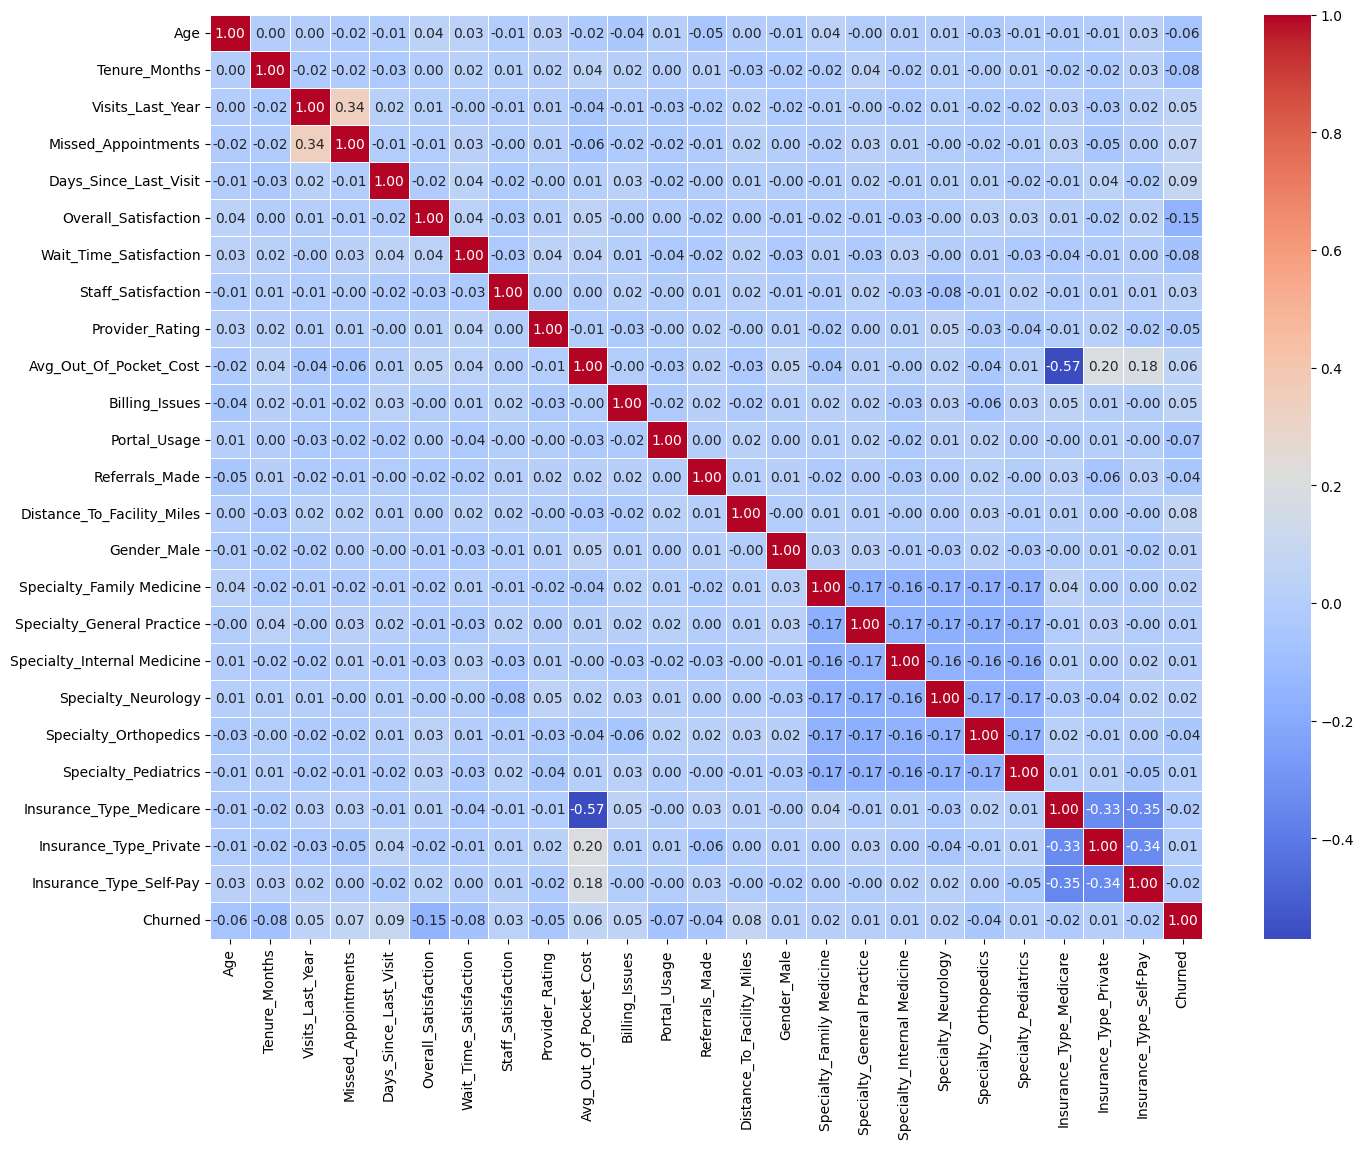

In [35]:
# initial heatmap
corr = pd.concat([X, y], axis=1).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

Text(0.5, 1.0, 'Churned Value Counts')

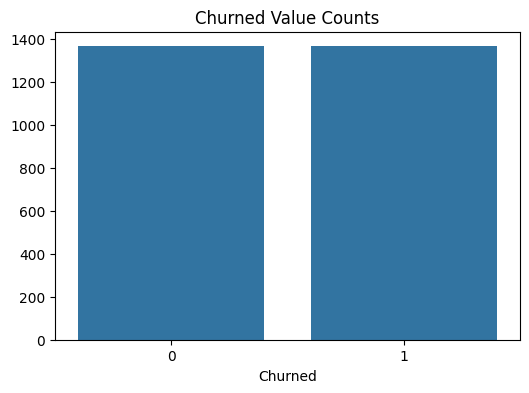

In [37]:
freq = y_res.value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=freq.index, y=freq.values)
plt.title('Churned Value Counts')

<Axes: >

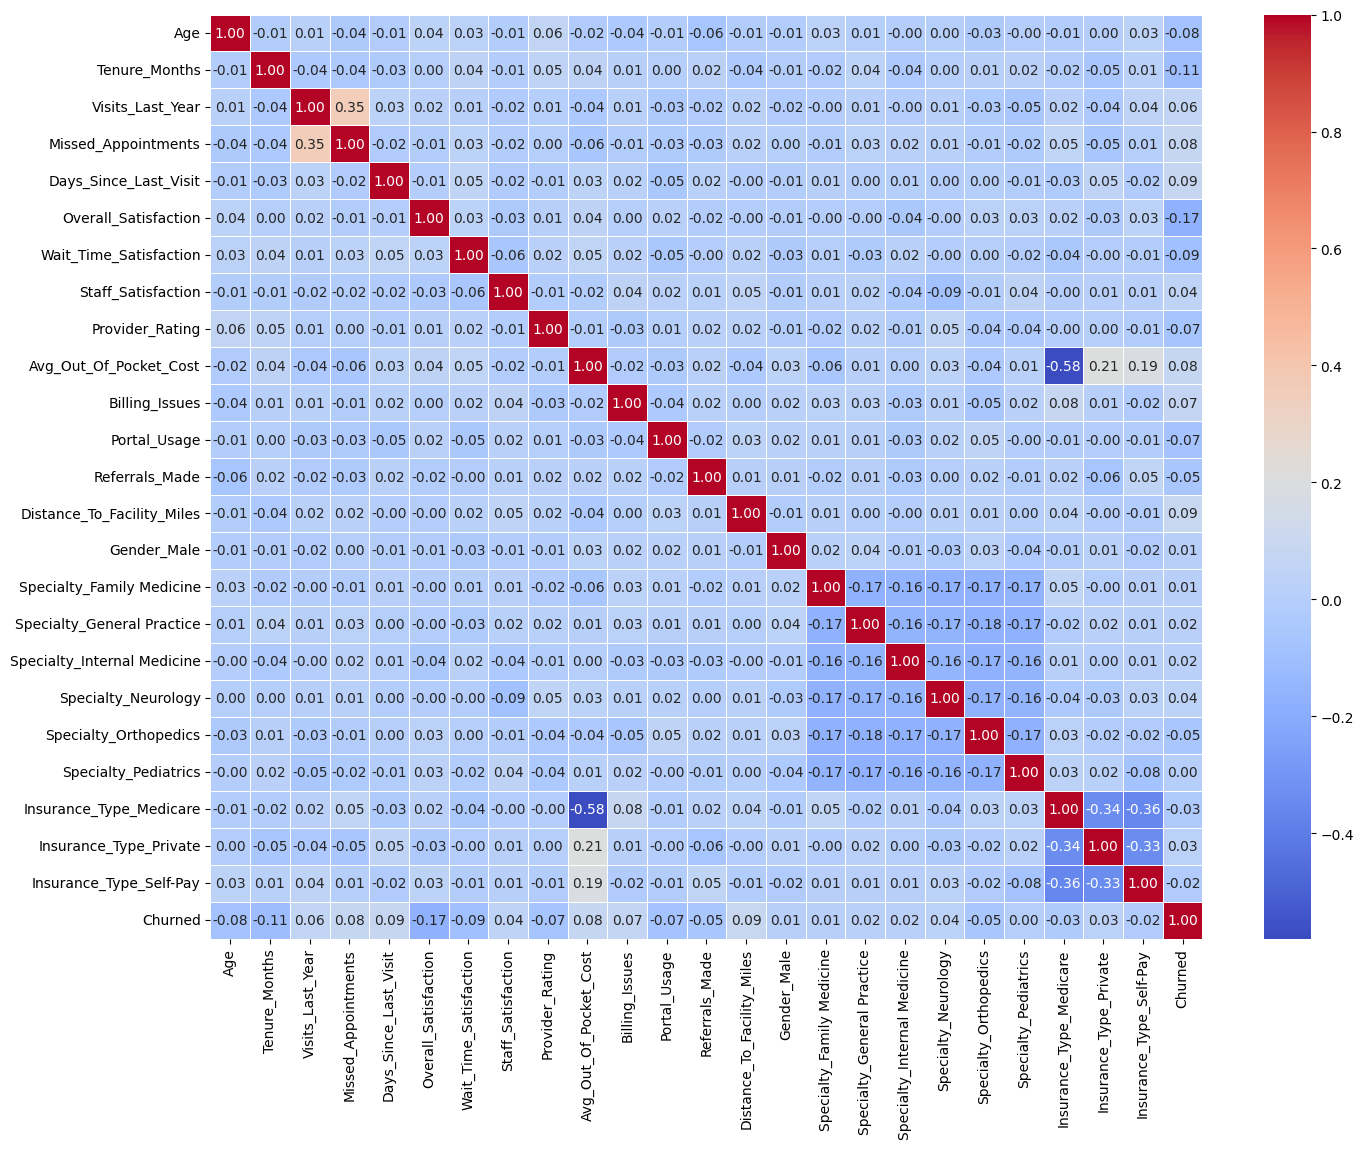

In [38]:
# heatmap after SMOTE

corr = pd.concat([X_res, y_res], axis=1).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(f"Training samples: {X_train.shape[0]}")

Training samples: 2187


# Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

Recall:   0.6462
F1-Score: 0.6393

--- Detailed Report ---
              precision    recall  f1-score   support

           0       0.63      0.61      0.62       270
           1       0.63      0.65      0.64       277

    accuracy                           0.63       547
   macro avg       0.63      0.63      0.63       547
weighted avg       0.63      0.63      0.63       547



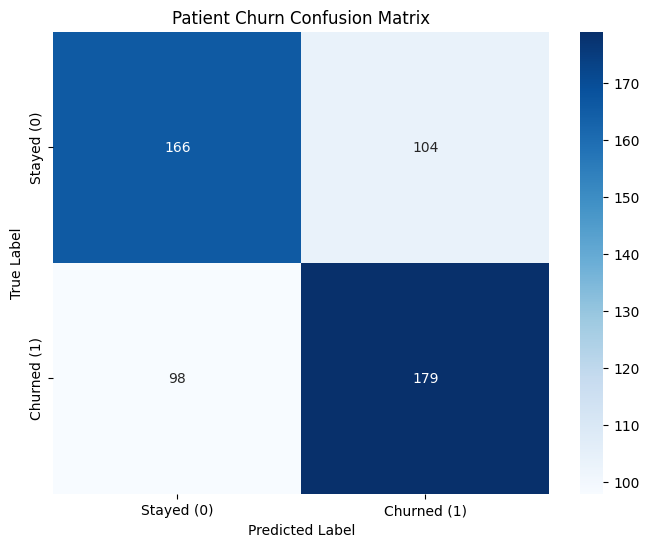

In [41]:
from sklearn.metrics import recall_score, f1_score, classification_report

# 1. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_lg = recall_score(y_test, lr_preds)

# 2. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_lg = f1_score(y_test, lr_preds)

print(f"Recall:   {recall_lg:.4f}")
print(f"F1-Score: {f1_lg:.4f}")

# 3. Optional: Get the full breakdown (includes Precision and Accuracy)
print("\n--- Detailed Report ---")
print(classification_report(y_test, lr_preds))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the matrix
cm = confusion_matrix(y_test, lr_preds)

# 2. Plot using Seaborn for a clean look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn Confusion Matrix')
plt.show()

# Decision Tree

Recall:   0.6245
F1-Score: 0.6419
Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.64      0.67      0.65       270
           1       0.66      0.62      0.64       277

    accuracy                           0.65       547
   macro avg       0.65      0.65      0.65       547
weighted avg       0.65      0.65      0.65       547



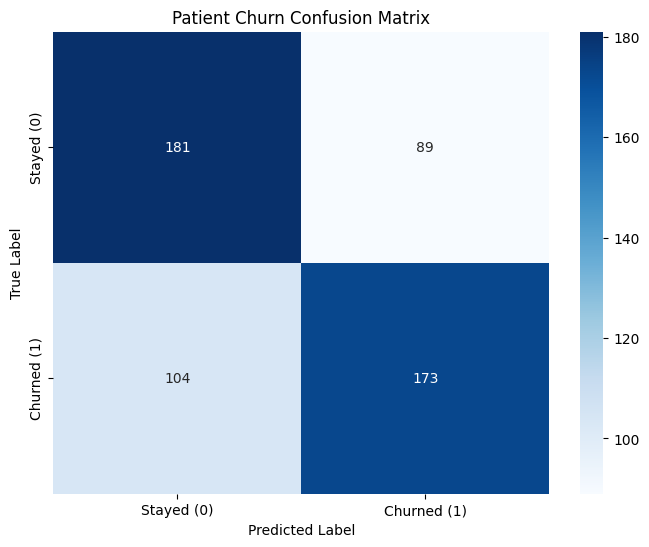

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
# We set max_depth to prevent the tree from growing infinitely (overfitting)

# dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=2)

# 2. Fit the model
dt_model.fit(X_train, y_train)

# 3. Make predictions
dt_preds = dt_model.predict(X_test)

# 4. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_dt = recall_score(y_test, dt_preds)

# 5. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_dt = f1_score(y_test, dt_preds)

print(f"Recall:   {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# 6. Evaluate
print("Decision Tree Performance:")
print(classification_report(y_test, dt_preds))

# 7. Generate the matrix
cm = confusion_matrix(y_test, dt_preds)

# 8. Plot using Seaborn for a clean look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn Confusion Matrix')
plt.show()

# random forest

Recall:   0.8592
F1-Score: 0.8068
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       270
           1       0.76      0.86      0.81       277

    accuracy                           0.79       547
   macro avg       0.80      0.79      0.79       547
weighted avg       0.80      0.79      0.79       547



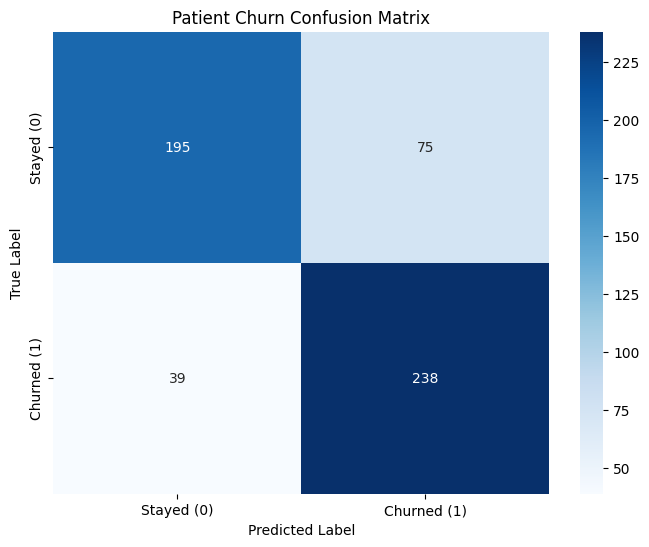

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 1. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_rf = recall_score(y_test, y_pred_rf)

# 2. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Recall:   {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print(classification_report(y_test, y_pred_rf))

# 3. Generate the matrix
cm = confusion_matrix(y_test, y_pred_rf)

# 4. Plot using Seaborn for a clean look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn Confusion Matrix')
plt.show()

# KNN

Recall:   0.4332
F1-Score: 0.5701
KNN Model Performance:
              precision    recall  f1-score   support

           0       0.61      0.91      0.73       270
           1       0.83      0.43      0.57       277

    accuracy                           0.67       547
   macro avg       0.72      0.67      0.65       547
weighted avg       0.72      0.67      0.65       547



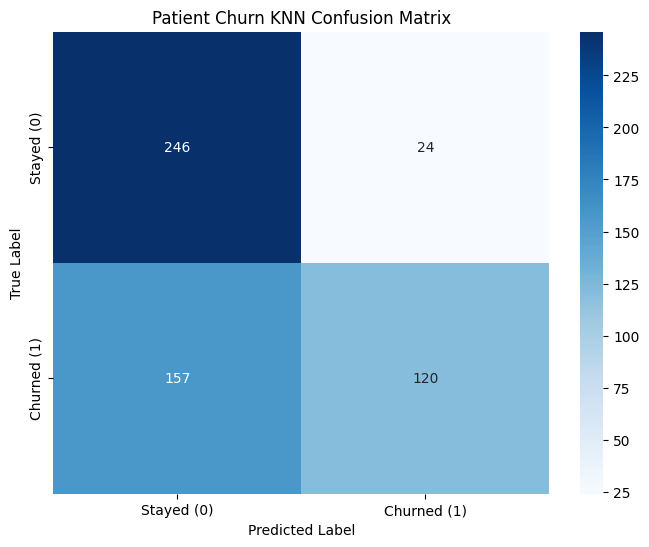

In [44]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize the model
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')

# 2. Fit the model
knn_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_knn = knn_model.predict(X_test)

# 4. Calculate Recall
# Measures: "Of all people who actually churned, how many did we catch?"
recall_knn = recall_score(y_test, y_pred_knn)

# 5. Calculate F1-Score
# Measures: The balance between catching churners and not being wrong too often.
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Recall:   {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

# 6. Evaluation Report
print("KNN Model Performance:")
print(classification_report(y_test, y_pred_knn))

# 7. Confusion Matrix Visualization
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Patient Churn KNN Confusion Matrix')
plt.show()

# comparing models

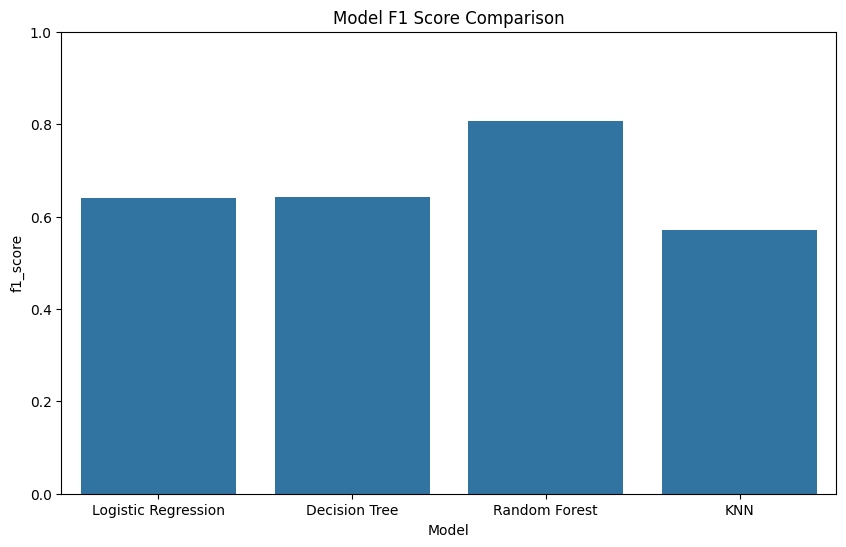

In [45]:
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'f1_score': [ f1_lg, f1_dt, f1_rf, f1_knn ]  })
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='f1_score', data=models_comparison)
plt.ylim(0, 1)
plt.title('Model F1 Score Comparison')
plt.show()

In [46]:
models_comparison.sort_values(by='f1_score', ascending=False)

,Model,f1_score
2,Random Forest,0.806780
1,Decision Tree,0.641929
0,Logistic Regression,0.639286
3,KNN,0.570071


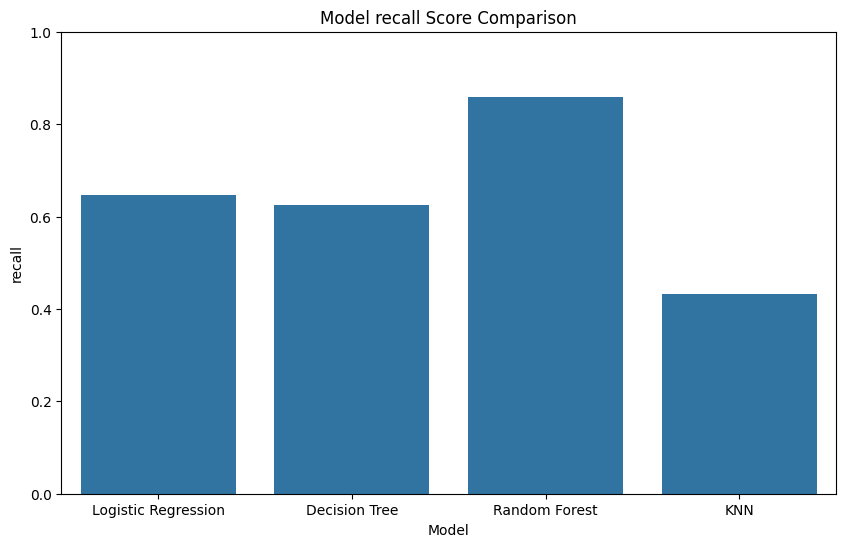

In [47]:
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'recall': [ recall_lg, recall_dt, recall_rf, recall_knn ]  })
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='recall', data=models_comparison)
plt.ylim(0, 1)
plt.title('Model recall Score Comparison')
plt.show()

In [48]:
models_comparison.sort_values(by='recall', ascending=False)

,Model,recall
2,Random Forest,0.859206
0,Logistic Regression,0.646209
1,Decision Tree,0.624549
3,KNN,0.433213
